# SigLIP 2 product image–description baseline

This notebook builds a base-level SigLIP2 image-text retrieval pipeline over the 10,000 Home & Kitchen product pairs in `data/meta_Home_and_Kitchen_siglip2_pairs_10k.csv`. It validates the real files, creates stable train/validation/test splits, converts paired images and descriptions into model inputs, runs a pretrained smoke test, and provides opt-in evaluation and fine-tuning stages.

The default path is intentionally safe on this Intel Mac: **Run All validates all 10,000 path pairs and performs a four-pair model forward pass, but it does not launch full CPU evaluation or training.**

## 0. Environment and run controls

Use the **RecSystem — SigLIP2 (Python 3.11)** kernel. The repository-local environment is `.venv-siglip2`, and its exact direct dependencies are in `notebooks/requirements-siglip2.txt`. Environment setup and every major decision are recorded in `notebooks/siglip2_decision_journal.md`.

One-time setup from the repository root:

```bash
/Users/vachemacbook/.pyenv/versions/3.11.6/bin/python -m venv .venv-siglip2
.venv-siglip2/bin/python -m pip install -r notebooks/requirements-siglip2.txt
.venv-siglip2/bin/python -m ipykernel install --user --name recsystem-siglip2 --display-name "RecSystem — SigLIP2 (Python 3.11)"
```

The first model-enabled run downloads roughly 1.5 GB of checkpoint weights from Hugging Face. Set the expensive controls below only when the relevant hardware and time are available.

In [1]:
from contextlib import nullcontext
from importlib.metadata import version
from pathlib import Path
import json
import platform
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModel, AutoProcessor

SEED = 42
RUN_MODEL_SMOKE_TEST = True   # downloads/loads the checkpoint, then runs four real pairs
RUN_FULL_BASELINE = False     # encodes the entire 1,000-row validation split
RUN_TRAINING = False          # starts the controlled fine-tuning section
RUN_FINAL_TEST = False        # evaluates the untouched 1,000-row test split
SAVE_ARTIFACTS = False        # requires RUN_FINAL_TEST=True

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
PIN_MEMORY = DEVICE.type == "cuda"
environment = {
    "python": platform.python_version(),
    "executable": sys.executable,
    "platform": platform.platform(),
    "device": str(DEVICE),
    "torch": torch.__version__,
    "numpy": np.__version__,
    "transformers": version("transformers"),
}
print(environment)

if sys.version_info[:2] != (3, 11):
    raise RuntimeError("Select the 'RecSystem — SigLIP2 (Python 3.11)' kernel before continuing.")
if torch.__version__.split("+")[0] != "2.2.2" or np.__version__ != "1.26.4":
    raise RuntimeError("This Intel-Mac notebook expects torch 2.2.2 and NumPy 1.26.4. See the decision journal.")
torch.from_numpy(np.zeros(1, dtype=np.float32))  # explicit ABI bridge smoke check

{'python': '3.11.6', 'executable': '/Users/vachemacbook/Desktop/RecSystem/RecSystem/.venv-siglip2/bin/python', 'platform': 'macOS-15.4.1-x86_64-i386-64bit', 'device': 'mps', 'torch': '2.2.2', 'numpy': '1.26.4', 'transformers': '4.57.6'}


tensor([0.])

## 1. Read and validate the actual 10K manifest

The CSV is the source of truth. Every row must have a unique ASIN, non-empty description, and an existing image path. No rows are silently dropped.

In [2]:
MANIFEST_RELATIVE_PATH = Path("data/meta_Home_and_Kitchen_siglip2_pairs_10k.csv")
REQUIRED_COLUMNS = ["asin", "description", "image_path"]

def find_project_root(start):
    for candidate in (start, *start.parents):
        if (candidate / MANIFEST_RELATIVE_PATH).is_file():
            return candidate
    raise FileNotFoundError(f"Could not find {MANIFEST_RELATIVE_PATH} from {start}")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
MANIFEST_PATH = PROJECT_ROOT / MANIFEST_RELATIVE_PATH
df = pd.read_csv(MANIFEST_PATH, dtype={column: "string" for column in REQUIRED_COLUMNS})
missing_columns = set(REQUIRED_COLUMNS).difference(df.columns)
if missing_columns:
    raise ValueError(f"Manifest is missing columns: {sorted(missing_columns)}")

df = df[REQUIRED_COLUMNS].copy()
for column in REQUIRED_COLUMNS:
    df[column] = df[column].fillna("").str.strip()
df["image_file"] = df["image_path"].map(lambda path: PROJECT_ROOT / path)
df["image_exists"] = df["image_file"].map(Path.is_file)
quality = {
    "rows": len(df),
    "duplicate_asins": int(df["asin"].duplicated().sum()),
    "empty_asins": int(df["asin"].eq("").sum()),
    "empty_descriptions": int(df["description"].eq("").sum()),
    "empty_image_paths": int(df["image_path"].eq("").sum()),
    "missing_images": int((~df["image_exists"]).sum()),
}
expected_quality = {
    "rows": 10_000, "duplicate_asins": 0, "empty_asins": 0,
    "empty_descriptions": 0, "empty_image_paths": 0, "missing_images": 0,
}
print(quality)
if quality != expected_quality:
    raise ValueError(f"Dataset validation failed. Expected {expected_quality}, received {quality}.")
display(df[REQUIRED_COLUMNS].head())

{'rows': 10000, 'duplicate_asins': 0, 'empty_asins': 0, 'empty_descriptions': 0, 'empty_image_paths': 0, 'missing_images': 0}


,asin,description,image_path
0,B00AT1G32Y,Enjoy a cool and comfortable night's sleep wit...,data/images/home_and_kitchen_10k/B00AT1G32Y.jpg
1,B09JKDNRRF,We provide you with unique designs and high-qu...,data/images/home_and_kitchen_10k/B09JKDNRRF.jpg
2,B01KP46PWW,Full Tang Cleaver. Triple riveted handle. 11 3...,data/images/home_and_kitchen_10k/B01KP46PWW.jpg
3,B007KQ6GHI,Henckels International makes essential kitchen...,data/images/home_and_kitchen_10k/B007KQ6GHI.jpg
4,B07G3684B3,Potato Ricer/Potato Masher/Stainless Steel Pot...,data/images/home_and_kitchen_10k/B07G3684B3.jpg


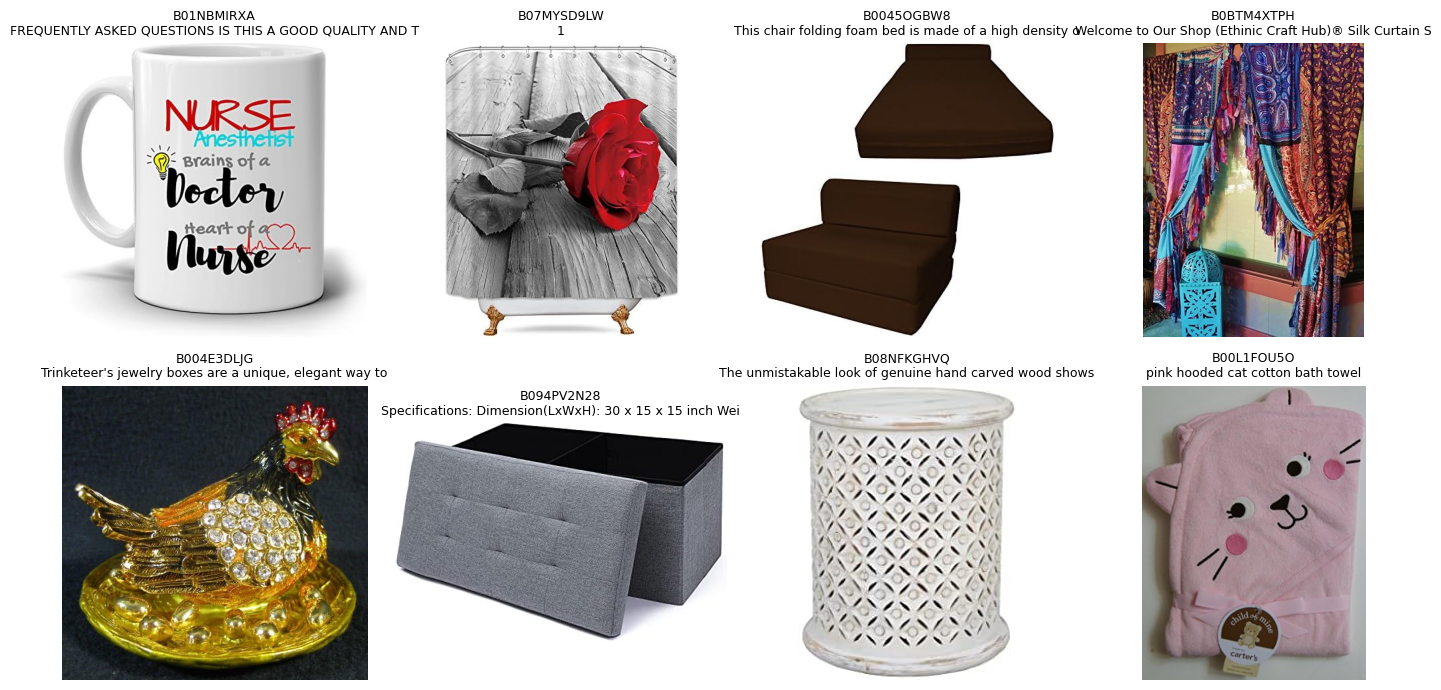

In [3]:
def open_rgb(path):
    with Image.open(path) as image:
        return image.convert("RGB")

preview = df.sample(8, random_state=SEED)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, row in zip(axes.flat, preview.itertuples()):
    ax.imshow(open_rgb(row.image_file))
    ax.set_title(f"{row.asin}\n{row.description[:55]}", fontsize=9)
    ax.axis("off")
plt.tight_layout()

## 2. Reproducible train/validation/test splits

The 80/10/10 split is saved by ASIN and validated every time it is reused. The exact ASIN never crosses partitions. Near-duplicate listings remain a known limitation for a later benchmark.

In [4]:
SPLIT_PATH = PROJECT_ROOT / "data/meta_Home_and_Kitchen_siglip2_splits_10k.csv"
EXPECTED_SPLIT_COUNTS = {"train": 8_000, "validation": 1_000, "test": 1_000}

if SPLIT_PATH.exists():
    split_map = pd.read_csv(SPLIT_PATH, dtype={"asin": "string", "split": "string"})
else:
    train_asins, holdout_asins = train_test_split(df["asin"], test_size=0.20, random_state=SEED)
    validation_asins, test_asins = train_test_split(holdout_asins, test_size=0.50, random_state=SEED)
    split_lookup = {
        **{asin: "train" for asin in train_asins},
        **{asin: "validation" for asin in validation_asins},
        **{asin: "test" for asin in test_asins},
    }
    split_map = pd.DataFrame({"asin": df["asin"], "split": df["asin"].map(split_lookup)})
    split_map.to_csv(SPLIT_PATH, index=False)

if list(split_map.columns) != ["asin", "split"]:
    raise ValueError("Split file must contain exactly the columns: asin, split")
if split_map["asin"].duplicated().any() or set(split_map["asin"]) != set(df["asin"]):
    raise ValueError("Split file must contain every manifest ASIN exactly once.")
split_counts = split_map["split"].value_counts().to_dict()
if split_counts != EXPECTED_SPLIT_COUNTS:
    raise ValueError(f"Expected split counts {EXPECTED_SPLIT_COUNTS}, received {split_counts}.")

df = df.merge(split_map, on="asin", how="left", validate="one_to_one")
train_df = df[df["split"].eq("train")].reset_index(drop=True)
val_df = df[df["split"].eq("validation")].reset_index(drop=True)
test_df = df[df["split"].eq("test")].reset_index(drop=True)
print(split_counts)

{'train': 8000, 'test': 1000, 'validation': 1000}


## 3. SigLIP2 processor, paired Dataset, and DataLoaders

`AutoProcessor` owns checkpoint-specific image resizing/normalization and text lowercasing/tokenization. SigLIP2 was trained with fixed padding and truncation to 64 text tokens, so this notebook preserves that preprocessing contract. The official FixRes checkpoint keeps the backwards-compatible `SiglipModel` configuration class even though its weights and model ID are SigLIP2.

In [5]:
MODEL_ID = "google/siglip2-base-patch16-224"
MAX_TEXT_LENGTH = 64
BATCH_SIZE = 16 if DEVICE.type == "cuda" else 4
NUM_WORKERS = 0  # reliable in Jupyter/macOS; tune in a standalone Linux training job
processor = AutoProcessor.from_pretrained(MODEL_ID)

class ProductPairs(Dataset):
    def __init__(self, frame):
        self.records = frame[["asin", "description", "image_file"]].to_dict("records")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        row = self.records[index]
        return {"asin": row["asin"], "text": row["description"], "image": open_rgb(row["image_file"])}

def collate_pairs(examples):
    model_inputs = processor(
        text=[example["text"] for example in examples],
        images=[example["image"] for example in examples],
        padding="max_length", truncation=True, max_length=MAX_TEXT_LENGTH, return_tensors="pt",
    )
    model_inputs["asins"] = [example["asin"] for example in examples]
    return model_inputs

def make_loader(frame, *, shuffle=False, batch_size=BATCH_SIZE):
    return DataLoader(
        ProductPairs(frame), batch_size=batch_size, shuffle=shuffle, num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY, collate_fn=collate_pairs, drop_last=False,
    )

train_loader = make_loader(train_df, shuffle=True)
val_loader = make_loader(val_df)
test_loader = make_loader(test_df)
sample_batch = next(iter(train_loader))
print({
    "model": MODEL_ID, "batch_size": BATCH_SIZE, "train_batches": len(train_loader),
    "sample_asins": sample_batch["asins"],
    "tensor_shapes": {key: tuple(value.shape) for key, value in sample_batch.items() if key != "asins"},
})

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


{'model': 'google/siglip2-base-patch16-224', 'batch_size': 4, 'train_batches': 2000, 'sample_asins': ['B00GGY9HD0', 'B08QL9CZDK', 'B074BBJRZG', 'B094S92NZH'], 'tensor_shapes': {'pixel_values': (4, 3, 224, 224), 'input_ids': (4, 64)}}


## 4. Pretrained model smoke test on real pairs

This is the smallest end-to-end proof: four descriptions and their four local images enter the two towers, producing aligned embeddings and a 4 × 4 similarity matrix. It is not yet a meaningful quality benchmark.

In [6]:
NEEDS_MODEL = RUN_MODEL_SMOKE_TEST or RUN_FULL_BASELINE or RUN_TRAINING or RUN_FINAL_TEST or SAVE_ARTIFACTS
model = None
if NEEDS_MODEL:
    model = AutoModel.from_pretrained(MODEL_ID).to(DEVICE)
    model.eval()
    parameter_count = sum(parameter.numel() for parameter in model.parameters())
    print(f"Loaded {model.__class__.__name__} with {parameter_count:,} parameters on {DEVICE}.")
else:
    print("Model loading is disabled by the run controls. Data and processor validation still completed.")

def move_tensors(batch):
    return {key: value.to(DEVICE, non_blocking=PIN_MEMORY) for key, value in batch.items() if key != "asins"}

if RUN_MODEL_SMOKE_TEST:
    with torch.inference_mode():
        smoke_outputs = model(**move_tensors(sample_batch), return_dict=True)
    smoke_probabilities = smoke_outputs.logits_per_image.sigmoid().cpu()
    display(pd.DataFrame(
        smoke_probabilities.numpy(),
        index=[f"image:{asin}" for asin in sample_batch["asins"]],
        columns=[f"text:{asin}" for asin in sample_batch["asins"]],
    ).round(3))
    print({
        "image_embeddings": tuple(smoke_outputs.image_embeds.shape),
        "text_embeddings": tuple(smoke_outputs.text_embeds.shape),
        "pairwise_logits": tuple(smoke_outputs.logits_per_image.shape),
        "finite_outputs": bool(torch.isfinite(smoke_outputs.logits_per_image).all()),
    })

Loaded SiglipModel with 375,187,970 parameters on mps.


,text:B00GGY9HD0,text:B08QL9CZDK,text:B074BBJRZG,text:B094S92NZH
image:B00GGY9HD0,0.008,0.000,0.001,0.000
image:B08QL9CZDK,0.000,0.004,0.000,0.000
image:B074BBJRZG,0.001,0.000,0.153,0.000
image:B094S92NZH,0.000,0.000,0.000,0.038


{'image_embeddings': (4, 768), 'text_embeddings': (4, 768), 'pairwise_logits': (4, 4), 'finite_outputs': True}


## 5. Optional full validation retrieval baseline

Set `RUN_FULL_BASELINE=True` in the controls and rerun from the model section. Each held-out image is ranked against all 1,000 validation descriptions, and the reverse direction is evaluated too. Recall@K checks whether the paired row appears in the top K.

In [7]:
def encode_loader(loader):
    all_asins, image_chunks, text_chunks = [], [], []
    model.eval()
    with torch.inference_mode():
        for batch in tqdm(loader, desc="Encoding image-text pairs"):
            all_asins.extend(batch["asins"])
            outputs = model(**move_tensors(batch), return_dict=True)
            image_chunks.append(F.normalize(outputs.image_embeds, dim=-1).cpu())
            text_chunks.append(F.normalize(outputs.text_embeds, dim=-1).cpu())
    return all_asins, torch.cat(image_chunks), torch.cat(text_chunks)

def paired_recall(image_embeddings, text_embeddings, ks=(1, 5, 10)):
    if image_embeddings.shape != text_embeddings.shape:
        raise ValueError("Image and text embedding matrices must have identical shapes.")
    similarities = image_embeddings @ text_embeddings.T
    targets = torch.arange(len(similarities))
    image_ranked = similarities.argsort(dim=1, descending=True)
    text_ranked = similarities.T.argsort(dim=1, descending=True)
    metrics = {}
    for k in ks:
        metrics[f"image_to_text_recall@{k}"] = ((image_ranked[:, :k] == targets[:, None]).any(1).float().mean().item())
        metrics[f"text_to_image_recall@{k}"] = ((text_ranked[:, :k] == targets[:, None]).any(1).float().mean().item())
    return metrics

baseline_metrics = None
val_asins = val_image_embeddings = val_text_embeddings = None
if RUN_FULL_BASELINE:
    val_asins, val_image_embeddings, val_text_embeddings = encode_loader(val_loader)
    baseline_metrics = paired_recall(val_image_embeddings, val_text_embeddings)
    display(pd.Series(baseline_metrics, name="pretrained_validation").to_frame())
else:
    print("Full validation encoding skipped. Set RUN_FULL_BASELINE=True when ready.")

Full validation encoding skipped. Set RUN_FULL_BASELINE=True when ready.


## 6. Optional controlled fine-tuning

SigLIP2 computes its pairwise sigmoid contrastive loss when `return_loss=True`: matching diagonal pairs are positive and the remaining in-batch combinations are negatives. The first run is deliberately limited to 512 training rows. Full-model training is not recommended on this Intel-Mac MPS environment; move that experiment to a CUDA Linux machine.

In [8]:
SMOKE_TEST_ROWS = 512  # set to None only on suitable training hardware
EPOCHS = 1
LEARNING_RATE = 1e-6
WEIGHT_DECAY = 0.01
GRADIENT_ACCUMULATION_STEPS = 4
MAX_GRAD_NORM = 1.0
training_frame = train_df.head(SMOKE_TEST_ROWS) if SMOKE_TEST_ROWS else train_df
training_loader = make_loader(training_frame, shuffle=True)

if RUN_TRAINING:
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    use_amp = DEVICE.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    optimizer.zero_grad(set_to_none=True)
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        for step, batch in enumerate(tqdm(training_loader, desc=f"Epoch {epoch + 1}"), start=1):
            autocast_context = torch.autocast("cuda", dtype=torch.float16) if use_amp else nullcontext()
            with autocast_context:
                loss = model(**move_tensors(batch), return_loss=True, return_dict=True).loss
                scaled_loss = loss / GRADIENT_ACCUMULATION_STEPS
            scaler.scale(scaled_loss).backward()
            should_step = step % GRADIENT_ACCUMULATION_STEPS == 0 or step == len(training_loader)
            if should_step:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
            running_loss += loss.item()
        print(f"epoch={epoch + 1} mean_loss={running_loss / len(training_loader):.4f}")
    model.eval()
else:
    print("Training skipped. Set RUN_TRAINING=True only after the pretrained smoke test succeeds.")

Training skipped. Set RUN_TRAINING=True only after the pretrained smoke test succeeds.


## 7. Optional final test, text search, and artifacts

The test split remains untouched until this section. If artifacts are enabled, vectors are L2-normalized and aligned row-for-row with `test_catalog.csv`.

In [9]:
test_metrics = None
test_asins = test_image_embeddings = test_text_embeddings = test_index = None
if RUN_FINAL_TEST:
    test_asins, test_image_embeddings, test_text_embeddings = encode_loader(test_loader)
    test_metrics = paired_recall(test_image_embeddings, test_text_embeddings)
    display(pd.Series(test_metrics, name="final_test").to_frame())
    test_index = test_df.set_index("asin").loc[test_asins].reset_index()

    def text_search(query, k=5):
        inputs = processor(text=[query], padding="max_length", truncation=True, max_length=MAX_TEXT_LENGTH, return_tensors="pt")
        with torch.inference_mode():
            query_embedding = model.get_text_features(**{key: value.to(DEVICE) for key, value in inputs.items()})
            query_embedding = F.normalize(query_embedding, dim=-1).cpu()[0]
        scores = test_image_embeddings @ query_embedding
        values, indices = scores.topk(min(k, len(scores)))
        results = test_index.iloc[indices.tolist()][REQUIRED_COLUMNS].copy()
        results.insert(1, "score", values.numpy())
        return results.reset_index(drop=True)

    display(text_search("modern wooden coffee table for a living room"))
else:
    print("Final test skipped. Enable it only after model choices are frozen.")

Final test skipped. Enable it only after model choices are frozen.


In [10]:
if SAVE_ARTIFACTS:
    if not RUN_FINAL_TEST:
        raise RuntimeError("SAVE_ARTIFACTS=True requires RUN_FINAL_TEST=True.")
    output_dir = PROJECT_ROOT / "models/siglip2_home_kitchen_10k"
    output_dir.mkdir(parents=True, exist_ok=True)
    np.save(output_dir / "test_image_embeddings.npy", test_image_embeddings.numpy())
    np.save(output_dir / "test_text_embeddings.npy", test_text_embeddings.numpy())
    test_index[REQUIRED_COLUMNS].to_csv(output_dir / "test_catalog.csv", index=False)
    with (output_dir / "metrics.json").open("w") as file:
        json.dump({"model_id": MODEL_ID, "validation": baseline_metrics, "test": test_metrics, "trained": RUN_TRAINING}, file, indent=2)
    if RUN_TRAINING:
        model.save_pretrained(output_dir / "checkpoint")
        processor.save_pretrained(output_dir / "checkpoint")
    print("Saved artifacts to", output_dir.resolve())
else:
    print("Artifact writing skipped.")

Artifact writing skipped.


## Practical next steps

1. Confirm the four-pair model smoke test is finite.
2. Run the full pretrained validation baseline once and record Recall@K.
3. Move the 512-row fine-tuning smoke test to a CUDA machine and confirm finite loss without retrieval collapse.
4. Group near-duplicate listings before creating a production benchmark.
5. Add human relevance judgments: semantic retrieval can have multiple valid products even though this paired metric recognizes only one.
6. Treat SigLIP2 similarity as a content signal; complementary product recommendation will still need behavioral/co-purchase features and a ranking objective.